Dataset_Loaded

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
dataset=pd.read_csv("/content/Employee_Promotion (1).csv")
dataset

,EmployeeID,Age,Gender,Experience,Salary,Department,PerformanceScore,TrainingHours,Promoted
0,1,25,Male,2,25000,Sales,60,10,0
1,2,28,Female,4,35000,IT,75,20,1
2,3,30,Male,5,40000,HR,70,15,1
3,4,22,Female,1,22000,Sales,50,5,0
4,5,35,Male,8,60000,IT,90,30,1
5,6,29,Female,3,32000,Finance,65,12,0
6,7,40,Male,10,75000,IT,95,40,1
7,8,26,Female,2,28000,HR,55,8,0
8,9,31,Male,6,45000,Finance,78,18,1
9,10,27,Female,3,30000,Sales,62,10,0


PHASE-1:Data Understanding

In [ ]:
print(len(dataset))   ###no of rows
print(len(dataset.columns))   ##no of columns
dataset.shape   ###shape of dataset
dataset.describe()   ##dataset information
dataset.info()   ##datatype of all coulmns
dataset.isnull().sum()   ##checked missing values
dataset.duplicated().sum()  ##checked dupliocates

50
9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EmployeeID        50 non-null     int64 
 1   Age               50 non-null     int64 
 2   Gender            50 non-null     object
 3   Experience        50 non-null     int64 
 4   Salary            50 non-null     int64 
 5   Department        50 non-null     object
 6   PerformanceScore  50 non-null     int64 
 7   TrainingHours     50 non-null     int64 
 8   Promoted          50 non-null     int64 
dtypes: int64(7), object(2)
memory usage: 3.6+ KB


np.int64(0)

PHASE-2:Exploratory Data Analysis (EDA)

In [ ]:
## 1.Employemnet analysis
dataset["Age"].mean()
dataset["Age"].min()
dataset["Age"].max()


## 2.Salary Analysis
dataset["Salary"].mean()
dataset["Salary"].min()
dataset["Salary"].max()


##3.Gender Analysis
dataset["Gender"].value_counts()

##4.Department Analysis
dataset.groupby("Department")["EmployeeID"].count()
dataset.groupby("Department")["Salary"].mean()


##5.Promotion analysis
dataset["Promoted"].sum()   ##promoted
(dataset["Promoted"]==0).sum()    ##not promoted
total_percentage=(dataset["Promoted"].sum()/len(dataset))*100
total_percentage

np.float64(54.0)

PHASE-3:Data Visualization

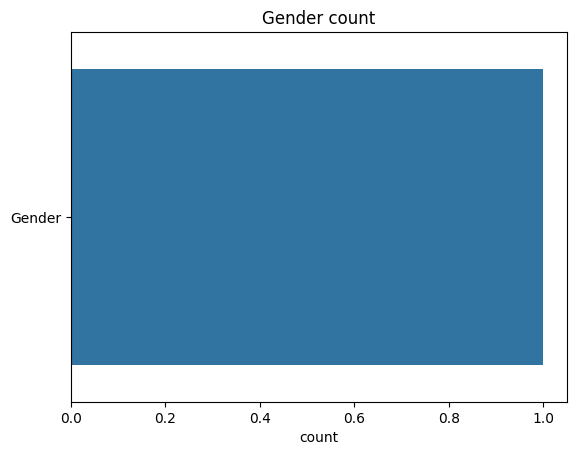

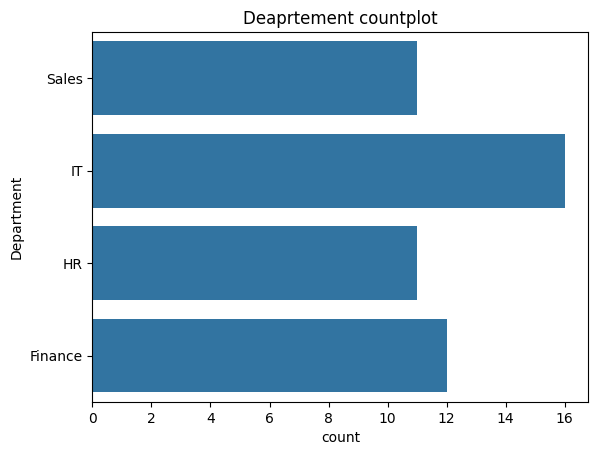

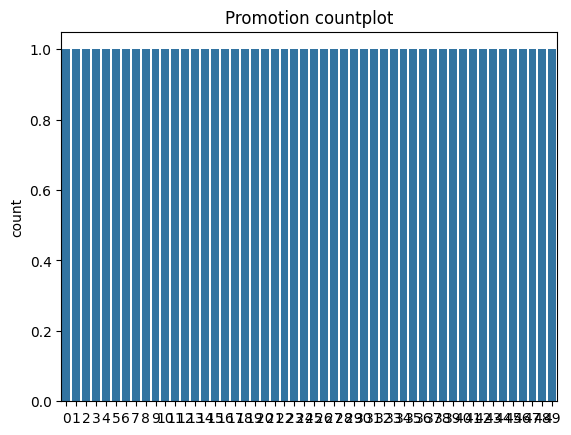

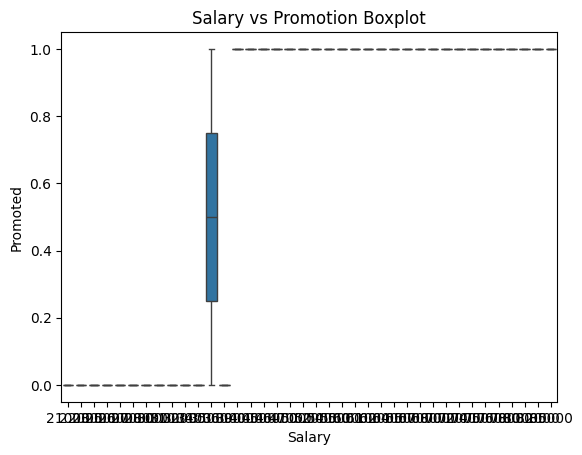

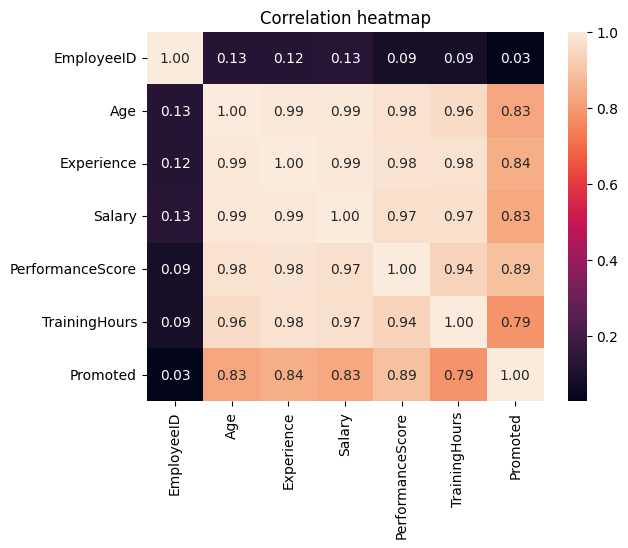

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

###1.salary distribution histogram
# plt.hist(dataset["Salary"])
# plt.title("Salary distribution")
# plt.ylabel("Frequency")
# plt.xlabel("Salary")
# plt.show()


###2.Gender countplot
sns.countplot("Gender")
plt.title("Gender count")
plt.show()


###3.Departement countplot
sns.countplot(dataset["Department"])
plt.title("Deaprtement countplot")
plt.show()


###4.Promotion countplot
sns.countplot(dataset["Promoted"])
plt.title("Promotion countplot")
plt.show()

# dataset.columns

###5.Salary vs Promotion Boxplot
sns.boxplot(x=dataset["Salary"],y=dataset["Promoted"])
plt.title("Salary vs Promotion Boxplot")
plt.show()

###6.Correlation heatmap
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation heatmap")
plt.show()

PHASE-4: FEATURE ENGINNERING

In [ ]:
### 1dataseteature: Experience_Level
def experience_level(exp):
    if exp <= 2:
        return "Beginner"
    elif exp <= 5:
        return "Intermediate"
    else:
        return "Expert"

dataset["Experience_Level"] = dataset["Experience"].apply(experience_level)
dataset



###2dataseteature 2: Salary_Per_Experience
dataset["Salary_Per_Experience"] = dataset["Salary"] / dataset["Experience"]
dataset


###3dataseteature 3: High_Pedatasetormer
import numpy as np
dataset["High_Performer"] = np.where(
    dataset["PerformanceScore"] >= 80,
    1,
    0
)


dataset

,EmployeeID,Age,Gender,Experience,Salary,Department,PerformanceScore,TrainingHours,Promoted,Experience_Level,Salary_Per_Experience,High_Performer
0,1,25,Male,2,25000,Sales,60,10,0,Beginner,12500.000000,0
1,2,28,Female,4,35000,IT,75,20,1,Intermediate,8750.000000,0
2,3,30,Male,5,40000,HR,70,15,1,Intermediate,8000.000000,0
3,4,22,Female,1,22000,Sales,50,5,0,Beginner,22000.000000,0
4,5,35,Male,8,60000,IT,90,30,1,Expert,7500.000000,1
5,6,29,Female,3,32000,Finance,65,12,0,Intermediate,10666.666667,0
6,7,40,Male,10,75000,IT,95,40,1,Expert,7500.000000,1
7,8,26,Female,2,28000,HR,55,8,0,Beginner,14000.000000,0
8,9,31,Male,6,45000,Finance,78,18,1,Expert,7500.000000,0
9,10,27,Female,3,30000,Sales,62,10,0,Intermediate,10000.000000,0


PHASE 5: Data Preprocessing

In [ ]:
dataset.isnull().sum()



##1. Encode Gender
dataset["Gender"] = dataset["Gender"].map({
    "Male": 1,
    "Female": 0
})


##2. Encode Department
dataset["Department"]=dataset["Department"].map({
"Sales":0,
"IT":1,
"HR":2,
"Finance":3

})

##3. Encode Experience_Level
dataset["Experience_Level_Encoded"] = dataset["Experience_Level"].map({
    "Beginner": 0,
    "Intermediate": 1,
    "Expert": 2
})


###4.Feature selection
X=dataset.drop("Promoted",axis=1)
y=dataset["Promoted"]

PHASE 6:TRAIN TEST AND SPLIT

In [ ]:
dataset = dataset.drop("Experience_Level", axis=1)
X = X.drop("Experience_Level", axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
dataset

(40, 11)
(10, 11)


,EmployeeID,Age,Gender,Experience,Salary,Department,PerformanceScore,TrainingHours,Promoted,Salary_Per_Experience,High_Performer,Experience_Level_Encoded
0,1,25,1,2,25000,0,60,10,0,12500.000000,0,0
1,2,28,0,4,35000,1,75,20,1,8750.000000,0,1
2,3,30,1,5,40000,2,70,15,1,8000.000000,0,1
3,4,22,0,1,22000,0,50,5,0,22000.000000,0,0
4,5,35,1,8,60000,1,90,30,1,7500.000000,1,2
5,6,29,0,3,32000,3,65,12,0,10666.666667,0,1
6,7,40,1,10,75000,1,95,40,1,7500.000000,1,2
7,8,26,0,2,28000,2,55,8,0,14000.000000,0,0
8,9,31,1,6,45000,3,78,18,1,7500.000000,0,2
9,10,27,0,3,30000,0,62,10,0,10000.000000,0,1


Phase 7: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)



Phase 8: Model Building

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Display Predictions
print("Predicted Values:")
print(y_pred)

Predicted Values:
[0 0 1 0 0 1 1 0 1 0]


Phase 9: Model Evaluation

Accuracy Score: 1.0

Confusion Matrix:
[[6 0]
 [0 4]]


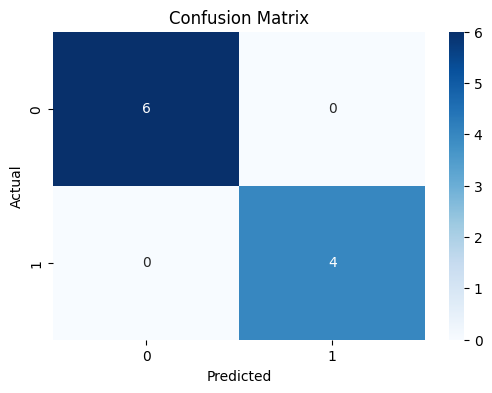


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Phase 10: Business Insights

1. Employees with higher Performance Scores are promoted more frequently.

2. Expert employees have higher promotion chances than beginners.

3. High performers are more likely to be promoted.

4. Salary and promotion show a positive relationship.

5. Employees with more experience generally have a higher probability of promotion.

In [ ]:
def predict_promotion(age,
                      gender,
                      experience,
                      salary,
                      department,
                      performance,
                      training):

    # Encode Gender
    gender_map = {
        "Male": 1,
        "Female": 0
    }

    # Encode Department
    department_map = {
        "Sales": 0,
        "IT": 1,
        "HR": 2,
        "Finance": 3
    }

    # Create Experience Level
    if experience <= 2:
        exp_level = 0      # Beginner
    elif experience <= 5:
        exp_level = 1      # Intermediate
    else:
        exp_level = 2      # Expert

    # Feature Engineering
    salary_per_experience = salary / max(experience, 1)

    high_performer = 1 if performance >= 80 else 0

    # Create Input Data
    new_data = pd.DataFrame([{
        "Age": age,
        "Gender": gender_map[gender],
        "Experience": experience,
        "Salary": salary,
        "Department": department_map[department],
        "PerformanceScore": performance,
        "TrainingHours": training,
        "Salary_Per_Experience": salary_per_experience,
        "High_Performer": high_performer,
        "Experience_Level_Encoded": exp_level
    }])

    # Scale Data
    new_data_scaled = scaler.transform(new_data)

    # Prediction
    prediction = model.predict(new_data_scaled)

    if prediction[0] == 1:
        return "Employee Likely To Be Promoted"
    else:
        return "Employee Not Likely To Be Promoted"

Bonus Tasks

In [ ]:
import pickle
from sklearn.metrics import accuracy_score

# 1. Save Model
with open("promotion_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

# 2. Save Scaler
with open("promotion_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler Saved Successfully!")

# 3. Load Saved Model
with open("promotion_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# 4. Load Saved Scaler
with open("promotion_scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

print("Model and Scaler Loaded Successfully!")

# 5. Predict on Test Data using Loaded Model
loaded_predictions = loaded_model.predict(X_test)

print("\nPredictions from Loaded Model:")
print(loaded_predictions[:10])

# 6. Accuracy Check
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("\nAccuracy of Loaded Model:", loaded_accuracy)

Model Saved Successfully!
Scaler Saved Successfully!
Model and Scaler Loaded Successfully!

Predictions from Loaded Model:
[0 0 1 0 0 1 1 0 1 0]

Accuracy of Loaded Model: 1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# BEFORE FEATURE ENGINEERING
original_features = [
    "Age",
    "Gender",
    "Experience",
    "Salary",
    "Department",
    "PerformanceScore",
    "TrainingHours"
]

X_before = dataset[original_features]
y = dataset["Promoted"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_before,
    y,
    test_size=0.2,
    random_state=42
)

scaler_before = StandardScaler()

Xb_train = scaler_before.fit_transform(Xb_train)
Xb_test = scaler_before.transform(Xb_test)

model_before = LogisticRegression()

model_before.fit(Xb_train, yb_train)

pred_before = model_before.predict(Xb_test)

accuracy_before = accuracy_score(yb_test, pred_before)


# AFTER FEATURE ENGINEERING
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler_after = StandardScaler()

Xa_train = scaler_after.fit_transform(Xa_train)
Xa_test = scaler_after.transform(Xa_test)

model_after = LogisticRegression()

model_after.fit(Xa_train, ya_train)

pred_after = model_after.predict(Xa_test)

accuracy_after = accuracy_score(ya_test, pred_after)

print("Accuracy Before Feature Engineering :", accuracy_before)

print("Accuracy After Feature Engineering  :", accuracy_after)

print("Improvement :", accuracy_after - accuracy_before)

Accuracy Before Feature Engineering : 1.0
Accuracy After Feature Engineering  : 1.0
Improvement : 0.0
